# Evaluación de MLP y Ridge en Train y Validación

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## Cargar datos y modelos guardados

In [2]:
X_train = np.load("data/X_train_processed.npy")
X_val = np.load("data/X_val_processed.npy")
y_train_usd = np.load("data/y_train_usd.npy")
y_val_usd = np.load("data/y_val_usd.npy")
train_idx = np.load("data/X_train_index.npy")
val_idx = np.load("data/X_val_index.npy")

target_scaler = joblib.load("models/target_scaler_v2.joblib")
Y_MEAN = target_scaler["mean"]
Y_STD = target_scaler["std"]

checkpoint = torch.load("models/best_mlp_v2.pt", map_location=DEVICE, weights_only=False)
ridge = joblib.load("models/best_baseline_v2.joblib")

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Arquitectura MLP:", checkpoint["architecture_name"], checkpoint["hidden_layers"])
print("Hiperparámetros:", checkpoint["hyperparams"])
print(f'RMSE de validación guardado: ${checkpoint["val_rmse_usd"]:,.2f}')

Train: (934, 278) Val: (234, 278)
Arquitectura MLP: deep [256, 128, 64, 32]
Hiperparámetros: {'lr': 0.001, 'dropout': 0.1, 'weight_decay': 0.0001, 'batch_size': 32, 'max_epochs': 600, 'patience': 50}
RMSE de validación guardado: $22,500.09


## Reconstruir la MLP y generar predicciones

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

hidden = checkpoint["hidden_layers"]
dropout = checkpoint["hyperparams"]["dropout"]
mlp = MLP(X_train.shape[1], hidden, dropout).to(DEVICE)
mlp.load_state_dict(checkpoint["model_state_dict"])
mlp.eval()

def predict_mlp_usd(X):
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        pred_scaled = mlp(X_t).cpu().numpy()
    return pred_scaled * Y_STD + Y_MEAN

pred_mlp_train = predict_mlp_usd(X_train)
pred_mlp_val = predict_mlp_usd(X_val)
pred_ridge_train = ridge.predict(X_train)
pred_ridge_val = ridge.predict(X_val)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


## RMSE, MAE y R²

In [4]:
def metricas(y_true, y_pred):
    return {
        "RMSE_USD": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_USD": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

rows = []
for modelo, conjunto, y, pred in [
    ("MLP", "Train", y_train_usd, pred_mlp_train),
    ("MLP", "Validación", y_val_usd, pred_mlp_val),
    ("Ridge", "Train", y_train_usd, pred_ridge_train),
    ("Ridge", "Validación", y_val_usd, pred_ridge_val),
]:
    rows.append({"Modelo": modelo, "Conjunto": conjunto, **metricas(y, pred)})

metricas_df = pd.DataFrame(rows)
display(metricas_df.style.format({
    "RMSE_USD": "${:,.2f}",
    "MAE_USD": "${:,.2f}",
    "R2": "{:.4f}"
}))

,Modelo,Conjunto,RMSE_USD,MAE_USD,R2
0,MLP,Train,"$6,854.22","$4,746.73",0.9923
1,MLP,Validación,"$22,500.08","$15,484.95",0.9076
2,Ridge,Train,"$28,230.55","$16,215.56",0.8691
3,Ridge,Validación,"$31,360.03","$17,295.59",0.8205


## Comparación MLP vs. Ridge

In [5]:
def valor(modelo, conjunto, metrica):
    return metricas_df.loc[
        (metricas_df["Modelo"] == modelo) & (metricas_df["Conjunto"] == conjunto), metrica
    ].iloc[0]

comparacion = []
for conjunto in ["Train", "Validación"]:
    rmse_mlp = valor("MLP", conjunto, "RMSE_USD")
    rmse_ridge = valor("Ridge", conjunto, "RMSE_USD")
    comparacion.append({
        "Conjunto": conjunto,
        "RMSE_MLP": rmse_mlp,
        "RMSE_Ridge": rmse_ridge,
        "Mejora_USD": rmse_ridge - rmse_mlp,
        "Mejora_pct": 100 * (rmse_ridge - rmse_mlp) / rmse_ridge,
        "MLP_menor_30000": rmse_mlp < 30000,
    })

comparacion_df = pd.DataFrame(comparacion)
display(comparacion_df.style.format({
    "RMSE_MLP": "${:,.2f}", "RMSE_Ridge": "${:,.2f}",
    "Mejora_USD": "${:,.2f}", "Mejora_pct": "{:.2f}%"
}))

,Conjunto,RMSE_MLP,RMSE_Ridge,Mejora_USD,Mejora_pct,MLP_menor_30000
0,Train,"$6,854.22","$28,230.55","$21,376.32",75.72%,True
1,Validación,"$22,500.08","$31,360.03","$8,859.94",28.25%,True


## Precio real vs. predicho

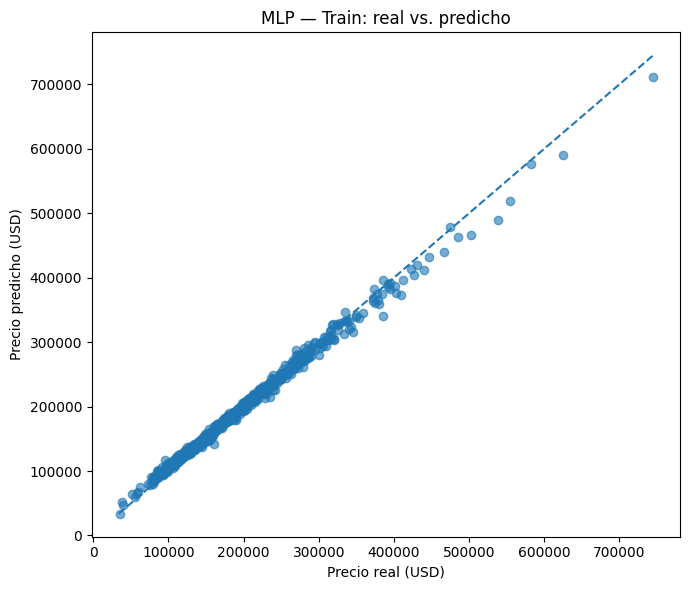

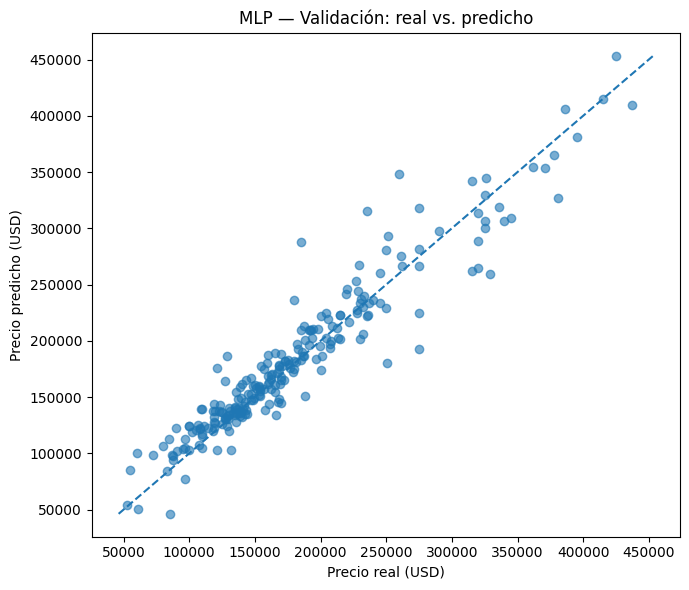

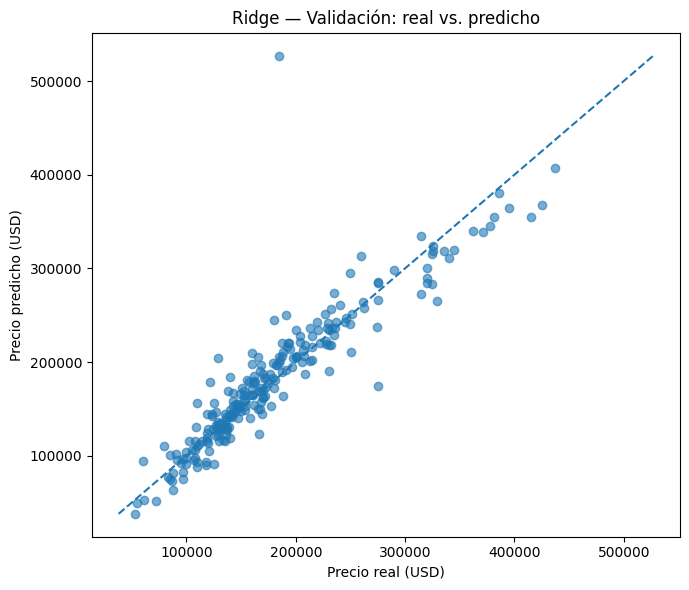

In [6]:
def grafica_real_predicho(y, pred, titulo):
    plt.figure(figsize=(7, 6))
    plt.scatter(y, pred, alpha=0.6)
    lo = min(y.min(), pred.min())
    hi = max(y.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], "--")
    plt.xlabel("Precio real (USD)")
    plt.ylabel("Precio predicho (USD)")
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

grafica_real_predicho(y_train_usd, pred_mlp_train, "MLP — Train: real vs. predicho")
grafica_real_predicho(y_val_usd, pred_mlp_val, "MLP — Validación: real vs. predicho")
grafica_real_predicho(y_val_usd, pred_ridge_val, "Ridge — Validación: real vs. predicho")

## Análisis de residuos

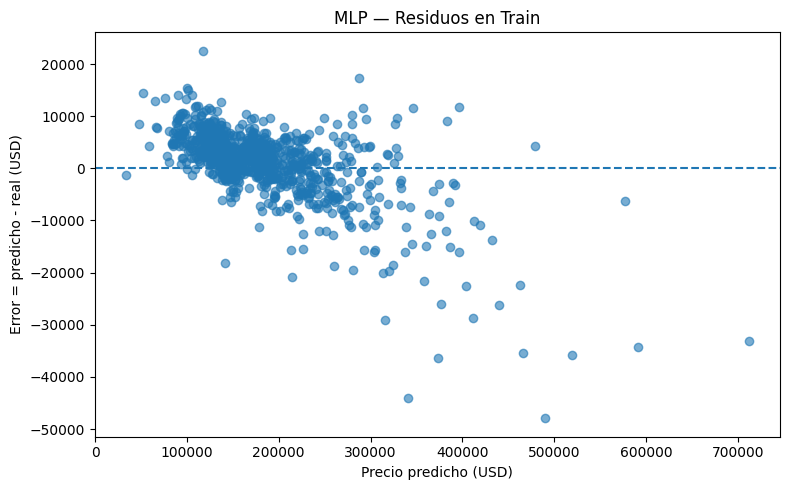

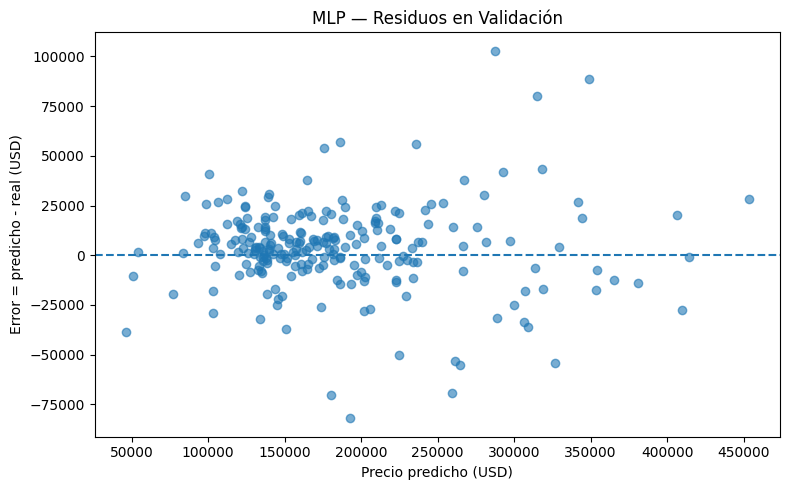

In [7]:
def grafica_residuos(y, pred, titulo):
    residuos = pred - y
    plt.figure(figsize=(8, 5))
    plt.scatter(pred, residuos, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Precio predicho (USD)")
    plt.ylabel("Error = predicho - real (USD)")
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

grafica_residuos(y_train_usd, pred_mlp_train, "MLP — Residuos en Train")
grafica_residuos(y_val_usd, pred_mlp_val, "MLP — Residuos en Validación")

## Mayores errores de la MLP

In [8]:
def tabla_errores(indices, y, pred, conjunto):
    df = pd.DataFrame({
        "indice_original": indices,
        "precio_real": y,
        "prediccion": pred,
    })
    df["error"] = df["prediccion"] - df["precio_real"]
    df["error_absoluto"] = np.abs(df["error"])
    df["error_pct"] = 100 * df["error"] / df["precio_real"]
    df["conjunto"] = conjunto
    return df.sort_values("error_absoluto", ascending=False).reset_index(drop=True)

errores_train = tabla_errores(train_idx, y_train_usd, pred_mlp_train, "Train")
errores_val = tabla_errores(val_idx, y_val_usd, pred_mlp_val, "Validación")

print("10 mayores errores — TRAIN")
display(errores_train.head(10).style.format({
    "precio_real": "${:,.2f}", "prediccion": "${:,.2f}",
    "error": "${:,.2f}", "error_absoluto": "${:,.2f}", "error_pct": "{:.2f}%"
}))

print("10 mayores errores — VALIDACIÓN")
display(errores_val.head(10).style.format({
    "precio_real": "${:,.2f}", "prediccion": "${:,.2f}",
    "error": "${:,.2f}", "error_absoluto": "${:,.2f}", "error_pct": "{:.2f}%"
}))

10 mayores errores — TRAIN


,indice_original,precio_real,prediccion,error,error_absoluto,error_pct,conjunto
0,1151,"$538,000.00","$490,046.44","$-47,953.56","$47,953.56",-8.91%,Train
1,719,"$385,000.00","$340,915.38","$-44,084.62","$44,084.62",-11.45%,Train
2,290,"$410,000.00","$373,657.56","$-36,342.44","$36,342.44",-8.86%,Train
3,537,"$555,000.00","$519,134.88","$-35,865.12","$35,865.12",-6.46%,Train
4,208,"$501,837.00","$466,413.62","$-35,423.38","$35,423.38",-7.06%,Train
5,539,"$625,000.00","$590,672.75","$-34,327.25","$34,327.25",-5.49%,Train
6,173,"$745,000.00","$711,837.94","$-33,162.06","$33,162.06",-4.45%,Train
7,736,"$345,000.00","$315,827.56","$-29,172.44","$29,172.44",-8.46%,Train
8,763,"$440,000.00","$411,248.31","$-28,751.69","$28,751.69",-6.53%,Train
9,882,"$466,500.00","$440,221.50","$-26,278.50","$26,278.50",-5.63%,Train


10 mayores errores — VALIDACIÓN


,indice_original,precio_real,prediccion,error,error_absoluto,error_pct,conjunto
0,365,"$184,750.00","$287,645.69","$102,895.69","$102,895.69",55.69%,Validación
1,242,"$260,000.00","$348,641.56","$88,641.56","$88,641.56",34.09%,Validación
2,1005,"$274,970.00","$192,866.42","$-82,103.58","$82,103.58",-29.86%,Validación
3,591,"$235,000.00","$314,963.75","$79,963.75","$79,963.75",34.03%,Validación
4,554,"$250,580.00","$180,113.42","$-70,466.58","$70,466.58",-28.12%,Validación
5,253,"$328,900.00","$259,692.75","$-69,207.25","$69,207.25",-21.04%,Validación
6,379,"$129,000.00","$186,192.25","$57,192.25","$57,192.25",44.34%,Validación
7,308,"$180,000.00","$236,094.11","$56,094.11","$56,094.11",31.16%,Validación
8,363,"$319,900.00","$264,406.19","$-55,493.81","$55,493.81",-17.35%,Validación
9,806,"$381,000.00","$326,814.25","$-54,185.75","$54,185.75",-14.22%,Validación


## Diagnóstico de generalización

In [9]:
rmse_train = valor("MLP", "Train", "RMSE_USD")
rmse_val = valor("MLP", "Validación", "RMSE_USD")
gap = rmse_val - rmse_train
ratio = rmse_val / rmse_train

print(f"RMSE MLP Train:      ${rmse_train:,.2f}")
print(f"RMSE MLP Validación: ${rmse_val:,.2f}")
print(f"Gap Val - Train:     ${gap:,.2f}")
print(f"Ratio Val/Train:      {ratio:.2f}x")
print(f"Objetivo Val < $30,000: {'ALCANZADO' if rmse_val < 30000 else 'NO ALCANZADO'}")

if ratio <= 1.20:
    print("Diagnóstico: train y validación tienen errores relativamente cercanos.")
elif ratio <= 1.50:
    print("Diagnóstico: existe una brecha moderada entre train y validación; conviene mencionarla al analizar generalización.")
else:
    print("Diagnóstico: la brecha train-validación es grande y puede indicar sobreajuste.")

RMSE MLP Train:      $6,854.22
RMSE MLP Validación: $22,500.08
Gap Val - Train:     $15,645.86
Ratio Val/Train:      3.28x
Objetivo Val < $30,000: ALCANZADO
Diagnóstico: la brecha train-validación es grande y puede indicar sobreajuste.


## Guardar tablas 

In [10]:
import os
os.makedirs("reports", exist_ok=True)
metricas_df.to_csv("reports/evaluacion_train_val_metricas.csv", index=False)
comparacion_df.to_csv("reports/evaluacion_train_val_comparacion.csv", index=False)
errores_train.to_csv("reports/errores_mlp_train.csv", index=False)
errores_val.to_csv("reports/errores_mlp_val.csv", index=False)
print("Resultados guardados en reports/.")

Resultados guardados en reports/.
